In [49]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist

In [51]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [53]:
print(f"Shape of x_train {x_train.shape}")
print(f"Shape of y_train {y_train.shape}")
print(f"Shape of x_test {x_test.shape}")
print(f"Shape of y_test {y_test.shape}")

Shape of x_train (60000, 28, 28)
Shape of y_train (60000,)
Shape of x_test (10000, 28, 28)
Shape of y_test (10000,)


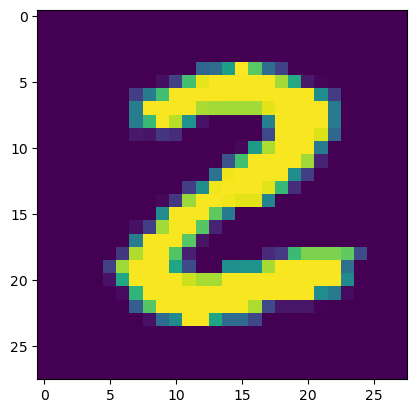

2


In [55]:
plt.imshow(x_train[25])
plt.show()
print(y_train[25])

In [57]:
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [59]:
x_train = x_train/255
x_test = x_test/255

In [61]:
print(x_train.shape,x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [63]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(50,activation = 'relu', name = 'L1'),
    keras.layers.Dense(50,activation = 'relu', name = 'L2'),
    keras.layers.Dense(10,activation = 'softmax', name = 'L3')
])

C:\Users\vinod\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [65]:
model.compile(
    optimizer = "sgd",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy'])

In [ ]:
history = model.fit(
    x_train,y_train,
    batch_size = 30,
    epochs = 10,
    validation_data = (x_test,y_test),
    shuffle = True
)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6833 - loss: 1.1327 - val_accuracy: 0.9047 - val_loss: 0.3299
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9092 - loss: 0.3215 - val_accuracy: 0.9247 - val_loss: 0.2631
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9242 - loss: 0.2664 - val_accuracy: 0.9304 - val_loss: 0.2402
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9331 - loss: 0.2340 - val_accuracy: 0.9390 - val_loss: 0.2102
Epoch 5/10
1755/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9382 - loss: 0.2164

<Axes: >

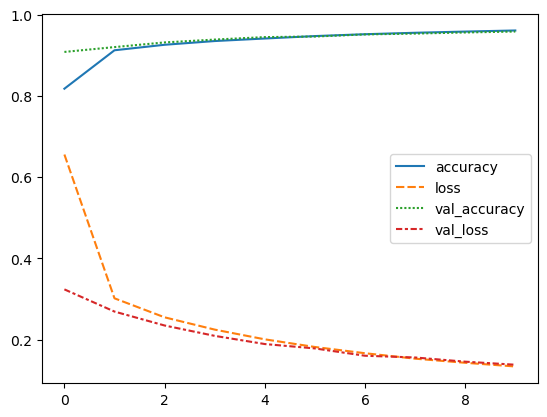

In [30]:
import seaborn as sns
sns.lineplot(model.history.history)

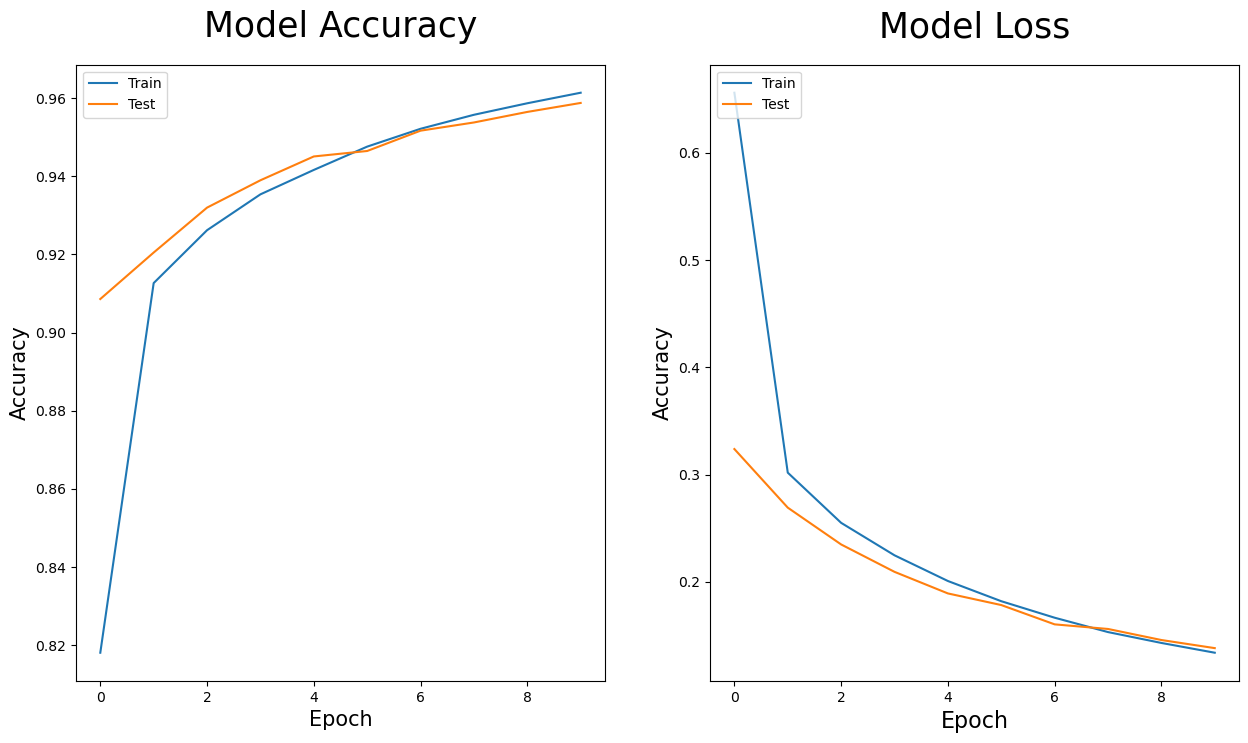

In [35]:
plt.figure(figsize = [15,8])
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy',size = 25, pad = 20)
plt.ylabel('Accuracy',size = 15)
plt.xlabel('Epoch',size = 15)
plt.legend(['Train', 'Test'],loc = 'upper left')
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss',size = 25, pad = 20)
plt.ylabel('Accuracy',size = 15)
plt.xlabel('Epoch',size = 16)
plt.legend(['Train','Test'],loc = 'upper left')
plt.show()

<Axes: >

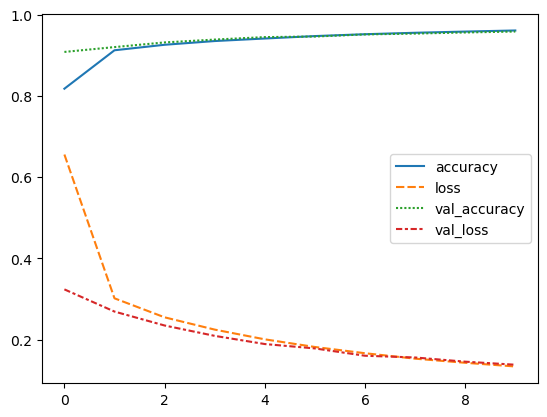

In [37]:
import seaborn as sns
sns.lineplot(model.history.history)

In [39]:
loss,accuracy = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9523 - loss: 0.1588


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


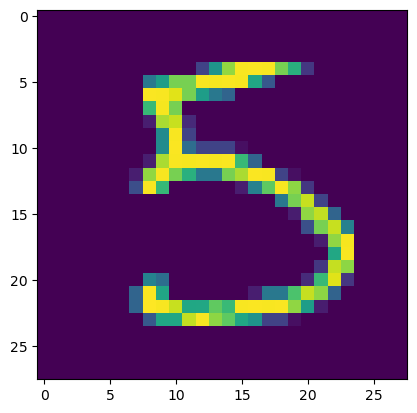

5


In [47]:
predicted_value = model.predict(x_test)
plt.imshow(x_test[15])
plt.show()
print(np.argmax(predicted_value[15],axis = 0))